# Bodrum Hotel & Destination Intelligence
## 20 - Hotel 360° Intelligence Summary

Google Travel customer voice + Trip.com customer voice + Trip traveler segments + Trip policies/amenities
+ master hotel data tek hotel-level katmanda birleştirilir. "En iyi otel" sıralaması YAPILMAZ (G4).

In [1]:

import sys
sys.path.insert(0, r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews\src")
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

from bodrum_intelligence.reviews.common import master_hotel_csv_path

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\hotel_360"
os.makedirs(FIG_DIR, exist_ok=True)

master = pd.read_csv(master_hotel_csv_path())
g_profile = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_profile_summary.csv")
t_profile = pd.read_csv(REPO_ROOT + r"\reports\tripcom_hotel_profile_summary.csv")
policy = pd.read_csv(REPO_ROOT + r"\data\processed\hotel_policies_features.csv")
voice_profiles = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_customer_voice_profiles.csv")
print("master:", len(master), "| google profiled:", len(g_profile), "| trip profiled:", len(t_profile), "| policy:", len(policy))


master: 192 | google profiled: 104 | trip profiled: 94 | policy: 95


## G2: Hotel 360 Master Table

In [2]:

base = master[["hotel_id","hotel_name","area","google_rating","google_review_count"]].rename(
    columns={"google_rating": "master_google_rating", "google_review_count": "master_google_review_count"})

g = g_profile.set_index("hotel_id")[["n_reviews","mean_rating","low_share","high_share"]].rename(
    columns={"n_reviews":"google_travel_review_n","mean_rating":"google_travel_mean_rating",
             "low_share":"google_travel_low_share","high_share":"google_travel_high_share"})
voice = voice_profiles.set_index("hotel_id")[["top_aspects","top_high_context_aspects","top_low_context_aspects"]].rename(
    columns={"top_high_context_aspects":"google_strength_signals","top_low_context_aspects":"google_concern_signals",
             "top_aspects":"google_top_aspects"})

t_cols = {"n":"trip_review_n"}
for c in ["mean_rating_5","low_share","high_share","top_traveler_type","family_share_pct","couple_share_pct","distinct_countries"]:
    if c in t_profile.columns:
        t_cols[c] = {"mean_rating_5":"trip_mean_rating_5","low_share":"trip_low_share","high_share":"trip_high_share",
                     "top_traveler_type":"trip_top_traveler_type","family_share_pct":"trip_family_share",
                     "couple_share_pct":"trip_couple_share","distinct_countries":"trip_country_coverage"}[c]
t = t_profile.set_index("hotel_id").rename(columns=t_cols)[[v for v in t_cols.values() if v in t_profile.rename(columns=t_cols).columns]]

pol = policy.set_index("hotel_id")[["policy_status","amenity_count","family_feature_count",
                                     "wellness_feature_count","water_feature_count"]]
pol["has_policy_data"] = True

hotel_360 = base.set_index("hotel_id").join([g, voice, t, pol], how="left").reset_index()
hotel_360["has_policy_data"] = hotel_360["has_policy_data"].fillna(False)
hotel_360["source_count"] = hotel_360[["google_travel_review_n","trip_review_n"]].notna().sum(axis=1)

DATA_PROCESSED = REPO_ROOT + r"\data\processed\hotel_360_intelligence.csv"
hotel_360.to_csv(DATA_PROCESSED, index=False)
assert hotel_360["hotel_id"].is_unique, "hotel_360 primary key (hotel_id) is not unique!"
print(f"Wrote {DATA_PROCESSED} ({len(hotel_360)} hotels, primary key unique confirmed)")
hotel_360.head(5)


Wrote C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews\data\processed\hotel_360_intelligence.csv (192 hotels, primary key unique confirmed)


,hotel_id,hotel_name,area,master_google_rating,master_google_review_count,google_travel_review_n,google_travel_mean_rating,google_travel_low_share,google_travel_high_share,google_top_aspects,...,trip_family_share,trip_couple_share,trip_country_coverage,policy_status,amenity_count,family_feature_count,wellness_feature_count,water_feature_count,has_policy_data,source_count
0,BOD001,Aksoy Taş Ev,Akyarlar,4.7,135,28.0,5.000000,0.000,1.000,BEACH_SEA;ROOM;FOOD;LOCATION;CLEANLINESS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1
1,BOD002,Armonia Holiday Village & Spa,Akyarlar,4.2,3197,10.0,3.600000,0.200,0.600,ROOM;FOOD;BAR_DRINKS;BED_COMFORT;STAFF,...,36.4,18.2,1.0,PARTIAL,11.0,4.0,3.0,1.0,True,2
2,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,4.3,246,30.0,4.433333,0.133,0.833,BEACH_SEA;STAFF;ROOM;CLEANLINESS;LOCATION,...,7.1,0.0,0.0,PARTIAL,3.0,1.0,0.0,1.0,True,2
3,BOD004,Bendis Beach Hotel,Akyarlar,3.9,2469,10.0,2.000000,0.700,0.300,ROOM;CLEANLINESS;FAMILY_KIDS;STAFF;PRICE_VALUE,...,36.4,18.2,2.0,PARTIAL,12.0,3.0,3.0,2.0,True,2
4,BOD005,ByAkkan,Akyarlar,4.4,203,10.0,4.600000,0.100,0.900,STAFF;FOOD;CLEANLINESS;ROOM;SERVICE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1


## G5: Confidence framework

In [3]:

def confidence(row):
    n_google = row.get("google_travel_review_n") or 0
    n_trip = row.get("trip_review_n") or 0
    has_policy = bool(row.get("has_policy_data"))
    sources = row.get("source_count") or 0
    if sources == 2 and (n_google >= 20 or n_trip >= 20) and has_policy:
        return "HIGH"
    if sources == 2 or (sources == 1 and max(n_google, n_trip) >= 20 and has_policy):
        return "MEDIUM"
    if sources >= 1:
        return "LOW"
    return "VERY_LOW"

hotel_360["customer_voice_support"] = hotel_360.apply(confidence, axis=1)
hotel_360.to_csv(DATA_PROCESSED, index=False)
hotel_360["customer_voice_support"].value_counts()


customer_voice_support
LOW         82
VERY_LOW    52
HIGH        44
MEDIUM      14
Name: count, dtype: int64

## Cross-platform rating gap / consistency (joined in, where available)

In [4]:

try:
    cross = pd.read_csv(REPO_ROOT + r"\reports\cross_platform_rating_comparison.csv")
    hotel_360 = hotel_360.merge(cross[["hotel_id","rating_gap_mean","comparison_support"]], on="hotel_id", how="left")
    hotel_360 = hotel_360.rename(columns={"rating_gap_mean":"cross_platform_rating_gap",
                                           "comparison_support":"cross_platform_consistency"})
    hotel_360.to_csv(DATA_PROCESSED, index=False)
    print("Cross-platform columns joined.")
except FileNotFoundError:
    print("cross_platform_rating_comparison.csv not found - skipping join.")


Cross-platform columns joined.


## G4: Rule-based archetypes (descriptive only - NO "best hotel" ranking)

In [5]:

def archetype(row):
    tags = []
    if row.get("customer_voice_support") in ("HIGH","MEDIUM"):
        gh = row.get("google_travel_high_share") or 0
        th = row.get("trip_high_share") or 0
        gl = row.get("google_travel_low_share") or 0
        tl = row.get("trip_low_share") or 0
        if gh >= 0.7 and (pd.isna(th) or th >= 0.6):
            tags.append("platform_consistent_strong_profile")
        if gl >= 0.3 or (pd.notna(tl) and tl >= 0.3):
            tags.append("platform_consistent_concern_profile")
    if (row.get("family_feature_count") or 0) >= 2 or (row.get("trip_family_share") or 0) >= 40:
        tags.append("family_oriented_profile")
    if (row.get("water_feature_count") or 0) >= 2:
        tags.append("beach_oriented_profile")
    if (row.get("wellness_feature_count") or 0) >= 2:
        tags.append("wellness_oriented_profile")
    cc = row.get("cross_platform_consistency")
    if cc == "SUPPORTED_COMPARISON" and abs(row.get("cross_platform_rating_gap") or 0) > 0.7:
        tags.append("source_divergent_profile")
    if row.get("customer_voice_support") == "VERY_LOW":
        tags.append("low_data_profile")
    return ";".join(tags) if tags else "insufficient_signal"

hotel_360["archetypes"] = hotel_360.apply(archetype, axis=1)
hotel_360.to_csv(DATA_PROCESSED, index=False)
hotel_360["archetypes"].value_counts().head(15)


archetypes
insufficient_signal                                                                                                                      66
low_data_profile                                                                                                                         50
platform_consistent_strong_profile;wellness_oriented_profile                                                                              9
platform_consistent_strong_profile;family_oriented_profile;wellness_oriented_profile                                                      7
family_oriented_profile;beach_oriented_profile;wellness_oriented_profile                                                                  7
platform_consistent_strong_profile                                                                                                        7
platform_consistent_strong_profile;family_oriented_profile;beach_oriented_profile;wellness_oriented_profile                               5
platform_

## G6: Hotel 360 profiles (sufficient-support hotels)

In [6]:

profiles = hotel_360[hotel_360["customer_voice_support"].isin(["HIGH","MEDIUM"])].copy()
profile_cols = ["hotel_id","hotel_name","area","customer_voice_support","google_travel_mean_rating",
                 "trip_mean_rating_5" if "trip_mean_rating_5" in profiles.columns else "google_travel_mean_rating",
                 "google_strength_signals","google_concern_signals","archetypes"]
profile_cols = [c for c in dict.fromkeys(profile_cols) if c in profiles.columns]
profiles_out = profiles[profile_cols]
profiles_out.to_csv(REPO_ROOT + r"\reports\hotel_360_profiles.csv", index=False)
print(f"{len(profiles_out)} hotels with HIGH/MEDIUM confidence profiled")
profiles_out.head(10)


58 hotels with HIGH/MEDIUM confidence profiled


,hotel_id,hotel_name,area,customer_voice_support,google_travel_mean_rating,trip_mean_rating_5,google_strength_signals,google_concern_signals,archetypes
1,BOD002,Armonia Holiday Village & Spa,Akyarlar,MEDIUM,3.600000,3.818182,ROOM;FOOD;BAR_DRINKS,CLEANLINESS;NOISE;POOL,family_oriented_profile;wellness_oriented_profile
2,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,HIGH,4.433333,3.678571,BEACH_SEA;STAFF;ROOM,SERVICE;MANAGEMENT;REFUND_PAYMENT,platform_consistent_strong_profile;source_dive...
3,BOD004,Bendis Beach Hotel,Akyarlar,MEDIUM,2.000000,3.954545,ANIMATION_ENTERTAINMENT;REFUND_PAYMENT,ROOM;CLEANLINESS;FAMILY_KIDS,platform_consistent_concern_profile;family_ori...
6,BOD007,Kefaluka Resort,Akyarlar,HIGH,4.066667,4.259091,STAFF;FOOD;ANIMATION_ENTERTAINMENT,SERVICE;RESERVATION;REFUND_PAYMENT,platform_consistent_strong_profile;family_orie...
7,BOD008,LA BREZZA SUITE &HOTEL,Akyarlar,HIGH,5.000000,4.009091,ROOM;STAFF;FOOD,NaN,platform_consistent_strong_profile;family_orie...
9,BOD010,Mare Garden Hotel,Akyarlar,MEDIUM,3.200000,4.000000,COMMUNICATION,LOCATION;HYGIENE;BAR_DRINKS,platform_consistent_concern_profile;beach_orie...
10,BOD011,"Radisson Collection Hotel, Bodrum",Akyarlar,MEDIUM,4.800000,4.750000,STAFF;BEACH_SEA;FOOD,NaN,platform_consistent_strong_profile;wellness_or...
11,BOD012,Selectum Collection Bodrum,Akyarlar,MEDIUM,4.100000,4.613636,FOOD;NOISE;ANIMATION_ENTERTAINMENT,FAMILY_KIDS,platform_consistent_strong_profile;family_orie...
12,BOD013,"Sentido Bellazure - Akyarlar, Bodrum / Turkey",Akyarlar,HIGH,4.027778,4.375000,FOOD;ROOM;STAFF,RESERVATION;HYGIENE;AIR_CONDITIONING,platform_consistent_strong_profile;family_orie...
13,BOD014,Suum Bodrum Hotel & Beach,Akyarlar,MEDIUM,4.600000,3.545455,BAR_DRINKS;ROOM;CLEANLINESS,MANAGEMENT,platform_consistent_strong_profile;wellness_or...


## Coverage summary

In [7]:

coverage = pd.DataFrame([{
    "master_hotel_count": len(master),
    "hotel_360_row_count": len(hotel_360),
    "google_only": int(((hotel_360["google_travel_review_n"].notna()) & (hotel_360["trip_review_n"].isna())).sum()),
    "trip_only": int(((hotel_360["trip_review_n"].notna()) & (hotel_360["google_travel_review_n"].isna())).sum()),
    "both_sources": int(((hotel_360["google_travel_review_n"].notna()) & (hotel_360["trip_review_n"].notna())).sum()),
    "no_review_source": int(((hotel_360["google_travel_review_n"].isna()) & (hotel_360["trip_review_n"].isna())).sum()),
    "has_policy_data_count": int(hotel_360["has_policy_data"].sum()),
}])
coverage.to_csv(REPO_ROOT + r"\reports\hotel_360_coverage.csv", index=False)
coverage


,master_hotel_count,hotel_360_row_count,google_only,trip_only,both_sources,no_review_source,has_policy_data_count
0,192,192,46,36,58,52,95


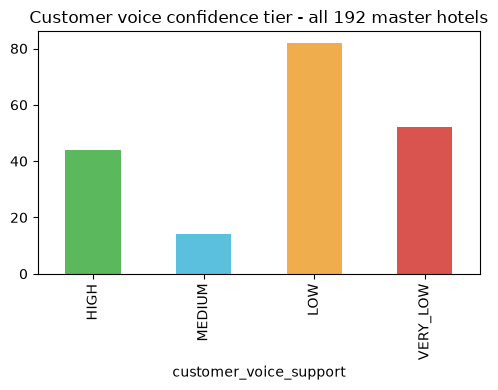

In [8]:

fig, ax = plt.subplots(figsize=(5,4))
hotel_360["customer_voice_support"].value_counts().reindex(["HIGH","MEDIUM","LOW","VERY_LOW"]).plot(
    kind="bar", ax=ax, color=["#5cb85c","#5bc0de","#f0ad4e","#d9534f"])
ax.set_title("Customer voice confidence tier - all 192 master hotels")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\confidence_tier_distribution.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Master listedeki 192 otelin her biri güven seviyesine (HIGH/MEDIUM/LOW/VERY_LOW) göre gruplanmıştır.
### Ne görüyoruz?
Kaç otel için gerçekten güvenilir bir customer-voice profili çıkarabildiğimiz.
### Neden önemli?
360° katmanın gerçek kapsamını abartısız gösterir.
### Dikkat edilmesi gereken nokta
VERY_LOW/LOW oteller için hiçbir iddia güvenilir değildir - bu segment gelecekteki discovery/scraping turları için hedef olabilir.

## G6: Final Key Findings (15-20)

In [9]:

findings = []
findings.append(f"Hotel 360 layer covers all {len(hotel_360)} master hotels, but only "
                 f"{(hotel_360['customer_voice_support'].isin(['HIGH','MEDIUM'])).sum()} have HIGH/MEDIUM confidence.")
findings.append(f"{coverage.iloc[0]['both_sources']} hotels have both Google Travel and Trip.com review data.")
findings.append(f"{coverage.iloc[0]['google_only']} hotels are Google-only, {coverage.iloc[0]['trip_only']} are Trip-only.")
findings.append(f"{coverage.iloc[0]['no_review_source']} master hotels still have zero review-source data from this pipeline.")
findings.append(f"{int(hotel_360['has_policy_data'].sum())} hotels have any Trip.com policy/amenity data.")
arch_counts = hotel_360["archetypes"].value_counts()
for arch, cnt in arch_counts.head(6).items():
    findings.append(f"Archetype '{arch}': {cnt} hotels.")
findings.append("No 'best hotel' ranking was produced - archetypes are descriptive, not comparative rankings.")
findings.append("Cross-platform rating gaps are a divergence signal only, not a quality verdict (see notebook 18).")
findings.append("Family/wellness/water feature counts come only from raw Trip.com policy text evidence, never inferred.")

key_findings_df = pd.DataFrame({"finding_id": range(1, len(findings)+1), "finding": findings})
key_findings_df.to_csv(REPO_ROOT + r"\reports\hotel_360_key_findings.csv", index=False)

with open(REPO_ROOT + r"\reports\hotel_360_summary.txt", "w", encoding="utf-8") as f:
    f.write("HOTEL 360 INTELLIGENCE SUMMARY\n" + "="*40 + "\n\n")
    for i, f_ in enumerate(findings, 1):
        f.write(f"{i}. {f_}\n")
for i, f_ in enumerate(findings, 1):
    print(f"{i}. {f_}")


1. Hotel 360 layer covers all 192 master hotels, but only 58 have HIGH/MEDIUM confidence.
2. 58 hotels have both Google Travel and Trip.com review data.
3. 46 hotels are Google-only, 36 are Trip-only.
4. 52 master hotels still have zero review-source data from this pipeline.
5. 95 hotels have any Trip.com policy/amenity data.
6. Archetype 'insufficient_signal': 66 hotels.
7. Archetype 'low_data_profile': 50 hotels.
8. Archetype 'platform_consistent_strong_profile;wellness_oriented_profile': 9 hotels.
9. Archetype 'platform_consistent_strong_profile;family_oriented_profile;wellness_oriented_profile': 7 hotels.
10. Archetype 'family_oriented_profile;beach_oriented_profile;wellness_oriented_profile': 7 hotels.
11. Archetype 'platform_consistent_strong_profile': 7 hotels.
12. No 'best hotel' ranking was produced - archetypes are descriptive, not comparative rankings.
13. Cross-platform rating gaps are a divergence signal only, not a quality verdict (see notebook 18).
14. Family/wellness/wa